In [1]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
from scipy.stats import linregress
import warnings
import matplotlib.pyplot as plt
# import sys
# sys.path.append('/home/robbie/custom_modules/')
from ll_xy import lonlat_to_xy
import kuka_tools as kt
import matplotlib.gridspec as gridspec
import itertools
from scipy.stats import binned_statistic as bs
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [2]:
data = pickle.load(open('20206_10_02_wfms','rb'))
freqs=['ku','ka']
nearfardict=pickle.load(open('nearfardict','rb'))

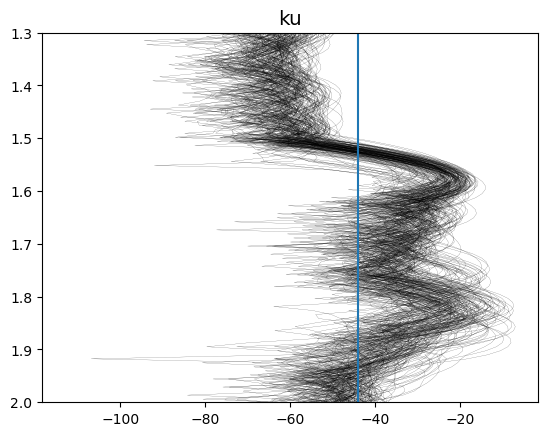

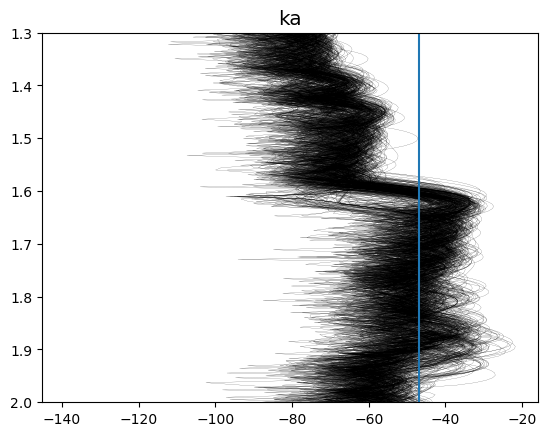

In [3]:
for freq in freqs:
    
    ranges=nearfardict[freq]['range']
    df = data[freq]
    
    for i in range(df.shape[0]):
        d = df.iloc[i]
        power=d['vv']
    
        plt.plot(10*np.log10(power),
             ranges,
             color='k',lw=0.1)
    
    
    plt.ylim(2,1.3)
    # plt.xlim(-10,0)
    if freq =='ka':
        plt.axvline(-47)
    elif freq=='ku':
        plt.axvline(-44)

    plt.title(freq,fontsize='x-large')
    plt.show()

# Analyse peaks

In [4]:
for freq in freqs:
    
    ranges=nearfardict[freq]['range']
    
    df = data[freq]
    
    thresh = -44 if freq =='ku' else -50
    
    npeaks = []
    
    # multi_peak_inds = {x:{} for x in range(1,5)}
    
    shifts=[]
    
    # peak_dfs=[]
    
    for i in range(df.shape[0]):
        
        power = df['vv'].iloc[i]
        
        # Identify all peaks more than 10% of max power
        
        ### Identify the indexes of all local maxima
        
        max_inds = argrelextrema(power, np.greater)[0]
        
        ### Catalogue the characteristics of the local maxima
        
        list_of_dicts_for_df = [{'ind':q,'power':power[q],'range':nearfardict[freq]['range'][q]} for q in max_inds]
        
        ### Sort dataframe so modst powerful peaks at top
        
        peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power',ascending=False)
        
        max_power = peaks_df.iloc[0]['power']
        
        # Calculate power of each peak relative to max power
        # peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
        
        # Filter out weak peaks with a threshold to remove sidelobes
        peaks_df = peaks_df[10*np.log10(peaks_df['power'])>thresh]
        
        # Sort peaks into ascending range
        peaks_df = peaks_df.sort_values('range',ascending=True)
    
        # Append the index of the first significant peak to calculate waveform shifts
        shifts.append(peaks_df.iloc[0]['ind'])
        
        # # Log npeaks to main dataframe
        npeaks.append(peaks_df.shape[0])

    df['shifts']=shifts
    df['range_shift']=[ranges[int(x)] if ~np.isnan(x) else np.nan for x in df['shifts'] ]
    df['npeaks']=npeaks
    
    df = df[df['range_shift']<1.73]

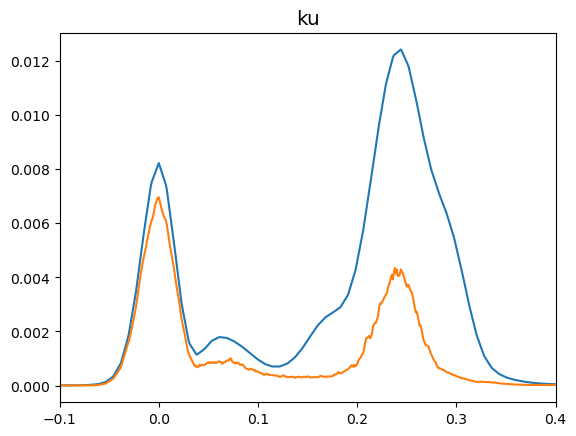

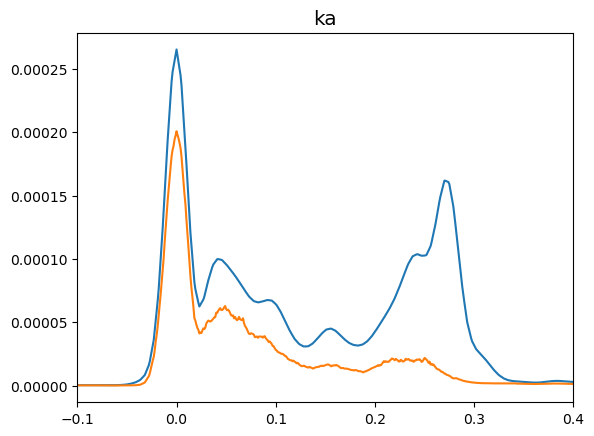

In [5]:
    
yints={'ka':[],'ku':[]}
peak_dfs = {'ku':[],'ka':[]}


for freq in freqs:

    df = data[freq]
    ranges=nearfardict[freq]['range']
    
    xinterp = np.arange(-0.1,0.50,0.001)
         

    for i in range(df.shape[0]):
    
        yinterp_vv = np.interp(xinterp,ranges-df['range_shift'].iloc[i],
                 df['vv'].iloc[i])
        
        yinterp_hv = np.interp(xinterp,ranges-df['range_shift'].iloc[i],
             df['hv'].iloc[i])
    
    
        ### Identify the indexes of all local maxima
        
        max_inds = argrelextrema(yinterp_vv, np.greater)[0]
        
        ### Catalogue the characteristics of the local maxima
        
        list_of_dicts_for_df = [{'ind':q,
                                 'vv_power':yinterp_vv[q],
                                 'hv_power':yinterp_hv[q],
                                 'range':xinterp[q]} for q in max_inds]
        
        ### Sort dataframe so modst powerful peaks at top
        
        peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('vv_power',
                                                                  ascending=False)
        
        max_power = peaks_df.iloc[0]['vv_power']
        
        # Calculate power of each peak relative to max power
        # peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
        
        # Filter out weak peaks with a threshold to remove sidelobes
        peaks_df = peaks_df[10*np.log10(peaks_df['vv_power'])>thresh]
        
        # Sort peaks into ascending range
        peaks_df = peaks_df.sort_values('range',ascending=True)
    
        # peaks_df = peaks_df[peaks_df['range']<0.12]
    
        peak_dfs[freq].append(peaks_df)
    
        if peaks_df.shape[0]>1:
    
            yints[freq].append(yinterp_vv)
    
    
    ymean = np.nanmean(yints[freq],axis=0)
    plt.plot(xinterp,ymean)
    
    if freq=='ku':pickle.dump(ymean,open('Figure3/roth_waveform.p','wb'))
    
    ymedian = np.nanmedian(yints[freq],axis=0)
    plt.plot(xinterp,ymedian)
    # plt.ylim(0,0.0002)
    
    plt.title(freq,fontsize='x-large')
    plt.xlim(-0.1,0.4)
    plt.show()

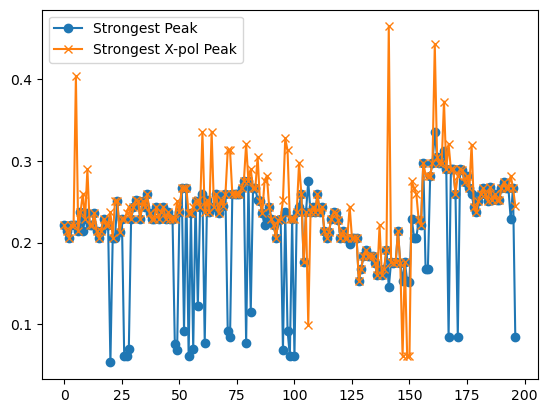

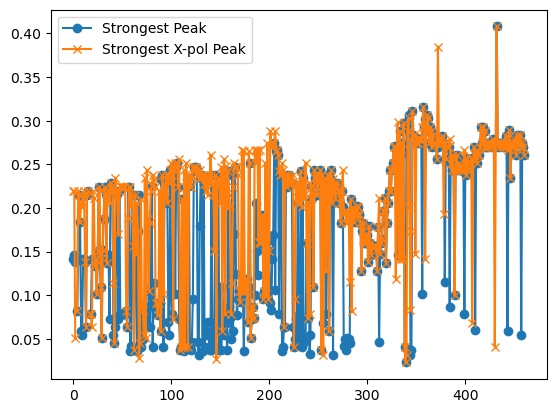

In [6]:
for freq in freqs:

    df = data[freq]
    
    counts_valid=[]
    
    r_rmaxs_valid=[]
    p_rmaxs=[]
    
    r_xmaxs_valid=[]
    p_xmaxs=[]
    
    r_amaxs_valid=[]
    p_amaxs=[]
    
    r_nearests=[]
    p_nearests=[]
    
    magna=[]
    
    p0=[]
    
    for count,peak_df in enumerate(peak_dfs[freq]):
    
        if peak_df.shape[0]>1:
    
            # magna_depth = float(df.iloc[count]['magna_depths']/100)
    
            # Calculate index of maximum power below the snow
            amax=np.argmax(peak_df.iloc[1:]['vv_power'])
            # Calculate range of peak with max power
            r_amax = peak_df.iloc[1:].iloc[amax]['range']
            # Calculate power of peak with max power
            a_amax = peak_df.iloc[1:].iloc[amax]['vv_power']        
            
            # Calculate range of furthest peak in range
            r_rmax = peak_df.iloc[-1]['range']
            a_rmax = peak_df.iloc[-1]['vv_power']
    
            # Calculate index of strongest x-pol power below the snow
            xmax=np.argmax(peak_df.iloc[1:]['hv_power'])
            # Calculate range of peak with max power
            r_xmax = peak_df.iloc[1:].iloc[xmax]['range']
            a_xmax = peak_df.iloc[1:].iloc[xmax]['vv_power']
    
    
            counts_valid.append(count)
            r_rmaxs_valid.append(r_rmax)
            r_amaxs_valid.append(r_amax)
            r_xmaxs_valid.append(r_xmax)
    
            p_rmaxs.append(a_rmax)
            p_amaxs.append(a_amax)
            p_xmaxs.append(a_xmax)
            
            p0.append(peak_df.iloc[0]['vv_power'])

        else:

            counts_valid.append(count)
            r_rmaxs_valid.append(np.nan)
            r_amaxs_valid.append(np.nan)
            r_xmaxs_valid.append(np.nan)
    
            p_rmaxs.append(np.nan)
            p_amaxs.append(np.nan)
            p_xmaxs.append(np.nan)
            
            p0.append(peak_df.iloc[0]['vv_power'])
            

            
    
            
        
    # plt.plot(counts_valid,r_rmaxs_valid,label='Furthest Peak',marker='.')
    plt.plot(counts_valid,r_amaxs_valid,label='Strongest Peak',marker='o')
    plt.plot(counts_valid,r_xmaxs_valid,label='Strongest X-pol Peak',marker='x')
    # plt.plot(counts_valid,r_nearests,label='Nearest to Magna',marker='.')
    # plt.plot(counts_valid,magna,label='Magna',marker='.')
    plt.legend()
    plt.show()

    
    df['p0']=p0
    df['p_rmax']=p_rmaxs
    df['p_amax']=p_amaxs
    df['p_xmax']=p_xmaxs
    df['r_rmax']=r_rmaxs_valid
    df['r_amax']=r_amaxs_valid
    df['r_xmax']=r_xmaxs_valid

    products=['xmax','rmax','pmax','p0']
    ps=[p_xmaxs,p_rmaxs,p_amaxs,p0]
    
    powers={q:m for q,m in zip(products,ps)}
    pickle.dump(powers,open(f'/home/robbie/Dropbox/kuka_slush/code/ice_powers/02_{freq}_flood.p','wb'))

    # pickle.dump(df,open(f'/home/robbie/Dropbox/kuka_slush/code/ice_powers/{freq}_full_df.p','wb'))

    df.reset_index(inplace=True)
    
    if freq=='ka':
    
        df = df[df.index<410]
    
        df = df[df.index>25]
    ranges=nearfardict[freq]['range']
    pickle.dump((ranges,df),open(f'02_{freq}.p','wb'))


In [18]:
diffs=np.array(data['ku']['r_xmax']-data['ku']['r_amax'])
q=diffs[diffs==0]
len(q),len(diffs),len(q)/len(diffs)


(148, 197, 0.751269035532995)

In [19]:
freqs=['ku','ka']
dfs={}
ranges_dict = {}
for freq in freqs:
    ranges=nearfardict[freq]['range']
    ranges,df = pickle.load(open(f'02_{freq}.p','rb'))
    dfs[freq]= df
    ranges_dict[freq]=ranges

-0.0009681972755388735 0.013663318506665259
-0.0051021575927732155 0.018053875968462495


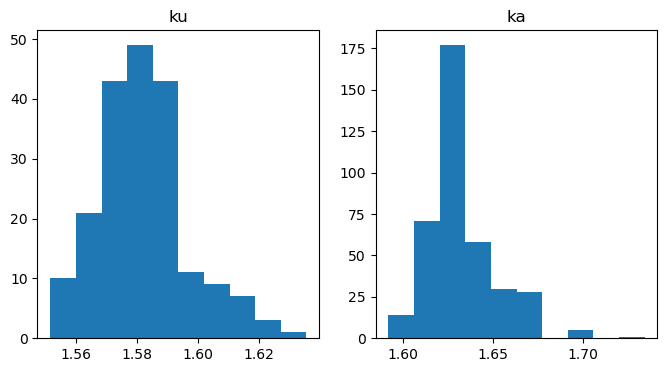

In [20]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(8,4))

for freq,ax in zip(freqs,[ax1,ax2]):
    df=dfs[freq]
    ax.hist(df['range_shift'])
    ax.set_title(freq)
    q=df['range_shift']-np.nanmean(df['range_shift'])
    print(np.nanmedian(q),np.nanstd(q))

plt.show()

In [21]:
for freq in freqs:
    df=dfs[freq]
    df.to_csv(f'index_chasing_02_tmp_{freq}.csv')

In [22]:
pit_indices_raw = {}
pit_indices={}

pit_indices_raw['ku']=  [161, 256, 336, 424, 525, 624, 66]
pit_indices['ku']=[5,37,71,94,123,161,182]

pit_indices_raw['ka'] = [232, 417, 560, 707, 877, 1081, 70]
pit_indices['ka'] = np.array([35, 113, 175, 221, 279, 354, 394])-25

In [23]:
echograms={}
echograms_hv={}
at_valids={}
s_ranges = {}

for freq in freqs:
    
    df=dfs[freq]
    
    ranges=nearfardict[freq]['range']
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120
        
    echogram=np.full((df.shape[0],n),np.nan)
    echogram=[]
    echogram_hv=[]
    at_valid=[]
    for i in range(df.shape[0]):
        d = df.iloc[i]
        power=d['vv']
        power_hv=d['hv']
        along_track=d['along_track']
        shift=d['shifts']
    
        if np.isnan(shift):
            echogram.append([np.nan]*n)
    
        else:
            
            shift=int(shift)
            
            shifted_ranges = ranges-ranges[shift]
            
            power_in_range = power[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            power_in_range_hv = power_hv[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            if i==0:
                print(power_in_range.shape)
            if power_in_range.shape[0]==n:
                echogram.append(power_in_range)
                echogram_hv.append(power_in_range_hv)
                at_valid.append(along_track)
    
    echograms[freq]=np.array(echogram)
    echograms_hv[freq]=np.array(echogram_hv)
    at_valids[freq]=np.array(at_valid)
    s_ranges[freq]=shifted_ranges
    

(72,)
(120,)


In [ ]:
sca

In [27]:
def make_echogram(ax,freq,leg_pad=1.2,pol='vv',lines_on=False,cmap='afmhot'):
    
    df=dfs[freq]
    ranges=ranges_dict[freq]
    
    if pol=='vv':echogram=echograms[freq]
    elif pol=='hv':echogram=echograms_hv[freq]
    shifted_ranges=s_ranges[freq]
    
    if freq=='ku':
        if pol=='vv':
            vmin=-45
            vmax=5
        elif pol=='hv':
            vmin=-70
            vmax=-20
        n=72
    elif freq=='ka':
        vmin=-60
        vmax=-10
        n=120

    im=ax.imshow(10*np.log10(echogram.T),vmin=vmin,vmax=vmax,cmap=cmap,aspect='auto')
    

    yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
    

    
    y_snow_depth_ind=[]
    y_wet_depth_ind=[]
    for ssd,swd in zip(scaled_snow_depths,scaled_dry_depths):
        #find index of closest shifted range bin to snow depth
        y_snow_depth_ind.append(np.argmin(np.abs(yaxis-ssd)))
        y_wet_depth_ind.append(np.argmin(np.abs(yaxis-swd)))

    r_xmax_ind=[]
    r_amax_ind=[]
    for rx,ra in zip(df['r_xmax'],df['r_amax']):
        r_xmax_ind.append(np.argmin(np.abs(yaxis-rx)))
        r_amax_ind.append(np.argmin(np.abs(yaxis-ra)))
    if lines_on:
        ax.plot(r_xmax_ind,color='crimson',label='CrossPol Max',lw=0.8)
        ax.plot(r_amax_ind,color='darkblue',label='CoPol Max',lw=0.8)
    
    # y_wet_depth_ind[0]=np.nan
    for i in pit_indices[freq]:
        ax.axvline(i,color='violet',lw=1)
    ax.scatter(pit_indices[freq],y_snow_depth_ind,zorder=1000,marker='^',color='cyan',label='Full Depth')
    ax.scatter(pit_indices[freq],y_wet_depth_ind,zorder=1000,marker='s',color='lime',label='Dry Depth',edgecolor='k')
    ax.legend(loc='center',bbox_to_anchor=(0.7,leg_pad),ncols=2,fontsize='small',framealpha=1)
    ax.set_xlabel('       Trace Number',fontsize='large',loc='left')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    tickspace=6 if freq=='ku' else 10
    yticks=np.arange(1,n,tickspace)
    ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
    ax.set_yticks(yticks,labels=ylabs)
    ax.set_ylabel('Range Below\nSnow Surf (m)',fontsize='large')
    cb=fig.colorbar(im,shrink=1,pad=0.01)
    cb.set_label('Power (dBm)')
    
    data_dict[freq]['yaxis']=yaxis

In [5]:
5.5,4,4,4,4.5,5.5,8.5

(5.5, 4, 4, 4, 4.5, 5.5, 8.5)

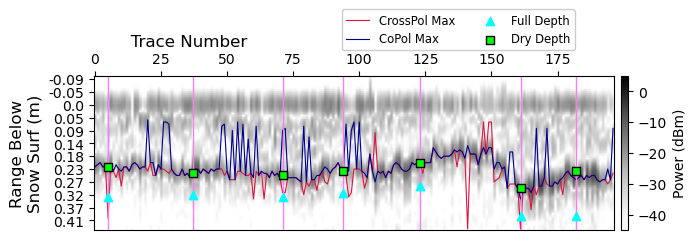

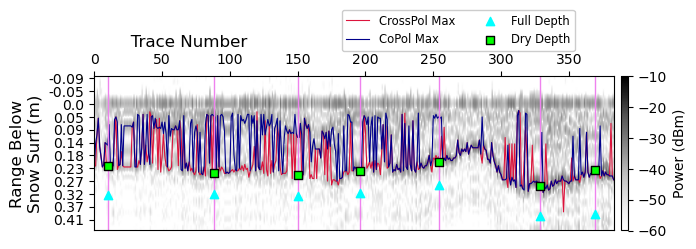

In [29]:
data_dict = {'ka':{},'ku':{}}

snow_depths=np.array([24,24.5,25,24,21.5,30,28])/100
wet_depths=np.array([5.5,4,4,4,4.5,5.5,8.5])/100

dry_scale_factor=1.2
wet_scale_factor=1.9
scaled_snow_depths = (snow_depths-wet_depths)*dry_scale_factor + (wet_depths*wet_scale_factor)
scaled_dry_depths = (snow_depths-wet_depths)*dry_scale_factor
    
for freq in freqs:
    
    fig,ax = plt.subplots(1,1,figsize=(8,2))

    
    make_echogram(ax,freq=freq,leg_pad=1.3,pol='vv',lines_on=True,cmap='Greys')
    ddir='/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/SuppFigs/'
    if freq=='ku':plt.savefig(f'{ddir}02_echogram_tracked.png',dpi=500,bbox_inches='tight')
    
    plt.show()


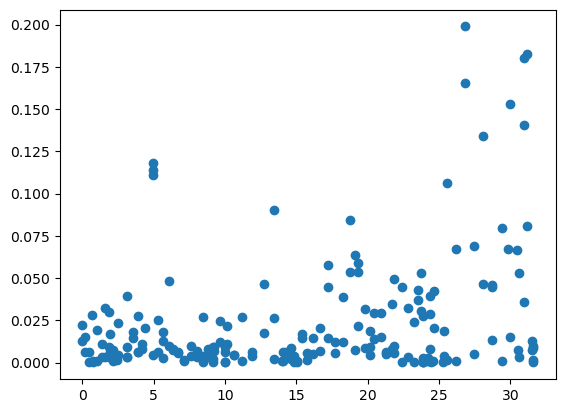

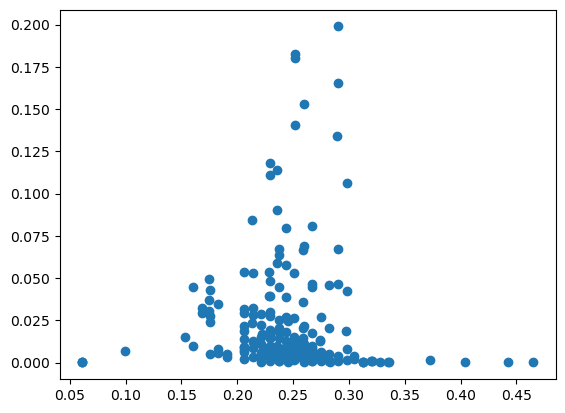

In [30]:
df=dfs['ku']
plt.scatter(df['along_track'],df['p_xmax'])
plt.show()
linregress(df['along_track'],df['p_xmax'])
plt.scatter(df['r_xmax'],df['p_xmax'])

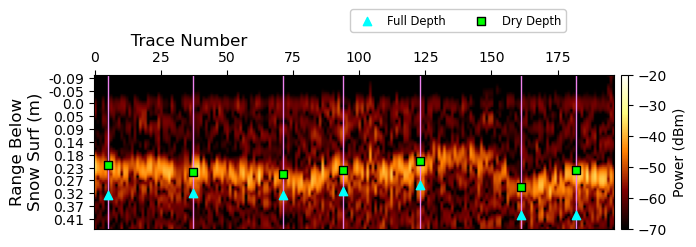

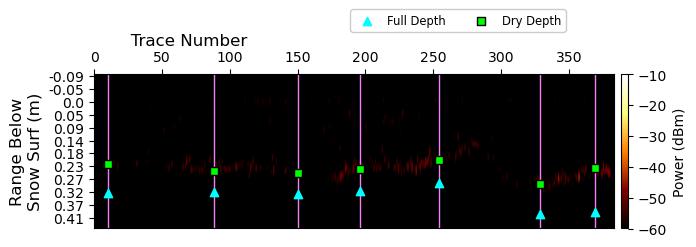

In [31]:
data_dict = {'ka':{},'ku':{}}
    
for freq in freqs:
    
    fig,ax = plt.subplots(1,1,figsize=(8,2))

    
    make_echogram(ax,freq=freq,leg_pad=1.35,pol='hv')

    
    
    plt.show()


In [32]:
pickle.dump(data_dict,open('data_dict.p','wb'))
pickle.dump(dfs,open('data_dict.p','wb'))

In [33]:
for freq in freqs:
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120

    
    df=dfs[freq]
    try:
        df.reset_index(inplace=True)
    except: pass
    
    ranges=ranges_dict[freq]
    shifted_ranges=s_ranges[freq]
    yaxis=data_dict[freq]['yaxis']

    thresh=0.1 if freq=='ku' else 0.2
        
    newx = yaxis[yaxis>thresh]
    
    radar_scat=[]
    mean_wfms=[]

    for i,ssd,swd in zip(pit_indices[freq],scaled_snow_depths,scaled_dry_depths):

        along_track = df['along_track'].iloc[i]

        arg_start = np.argmin(np.abs(df['along_track']-along_track-1))

        arg_end = np.argmin(np.abs(df['along_track']-along_track+1))

        print(i,arg_start,arg_end,arg_start-arg_end)

        

    print()

5 13 0 13
37 46 32 14
71 78 65 13
94 101 87 14
123 130 116 14
161 166 152 14
182 191 177 14

10 32 0 32
88 100 69 31
150 167 131 36
196 213 183 30
254 266 240 26
329 338 297 41
369 379 357 22



In [34]:
for freq in freqs:
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120

    
    df=dfs[freq]
    ranges=nearfardict[freq]['range']
    shifted_ranges=s_ranges[freq]
    yaxis=data_dict[freq]['yaxis']

    thresh=0.1 if freq=='ku' else 0.2
        
    newx = yaxis[yaxis>thresh]
    
    radar_scat=[]
    mean_wfms=[]

    for i,ssd,swd in zip(pit_indices[freq],scaled_snow_depths,scaled_dry_depths):
    
        window=10
        wfms=[]

        along_track = df['along_track'].iloc[i]
        arg_start = np.argmin(np.abs(df['along_track']-along_track-1))
        arg_end = np.argmin(np.abs(df['along_track']-along_track+1))

        for r in np.arange(arg_end,arg_start):
            
            d = df.iloc[r]
            power=d['vv']
            shift=int(d['shifts'])
            shifted_ranges = ranges-ranges[shift]
            power_in_range = power[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            if i==0:
                print(power_in_range.shape)
            if power_in_range.shape[0]==n:
                wfms.append(power_in_range)
    
    
        mean_wfm=np.nanmean(wfms,axis=0)
        mean_wfms.append(mean_wfm)
        newy=mean_wfm[yaxis>thresh]
        x_max=newx[np.argmax(newy)]
        radar_scat.append(x_max)

    data_dict[freq]['mean_wfms']=mean_wfms
    data_dict[freq]['radar_scats']=radar_scat
    print(radar_scat)
    print('done')

[np.float64(0.22125244140625), np.float64(0.23651123046875), np.float64(0.25177001953125), np.float64(0.2288818359375), np.float64(0.22125244140625), np.float64(0.30517578125), np.float64(0.25177001953125)]
done
[np.float64(0.2197265625), np.float64(0.24261474609375), np.float64(0.24261474609375), np.float64(0.23345947265625), np.float64(0.2105712890625), np.float64(0.27923583984375), np.float64(0.2471923828125)]
done


In [35]:
dfs

{'ku':      level_0  index                                                 vv  \
 0          0    150  [1.3351101637096273e-07, 1.970339822033165e-07...   
 1          1    151  [2.457150723971487e-07, 2.2502817136358877e-07...   
 2          2    152  [1.1955092723013433e-07, 1.1014129501241927e-0...   
 3          3    153  [6.144190463384196e-07, 4.524352482461088e-07,...   
 4          4    154  [3.3154920084815165e-07, 1.8520397445582303e-0...   
 ..       ...    ...                                                ...   
 192      192     92  [1.0072161348583384e-06, 9.636952591762593e-07...   
 193      193    330  [1.334384064229164e-06, 1.1708935973416682e-06...   
 194      194    331  [2.431523763697565e-06, 2.6839667778554035e-06...   
 195      195    333  [1.1972661896414676e-05, 8.75903182314678e-06,...   
 196      196    334  [2.4976470405388174e-08, 1.1469847562250164e-0...   
 
                                                     hv        vh        hh  \
 0    [1.2395

185.5823668461516
[np.float64(0.22125244140625), np.float64(0.23651123046875), np.float64(0.25177001953125), np.float64(0.2288818359375), np.float64(0.22125244140625), np.float64(0.30517578125), np.float64(0.25177001953125)]


/tmp/ipykernel_114856/938385648.py:81: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=[0.1,0.5,0.2])
/tmp/ipykernel_114856/938385648.py:85: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f'{over_dir}/F2.png',dpi=500,bbox_inches='tight')
/home/robbie/anaconda3/envs/flood/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


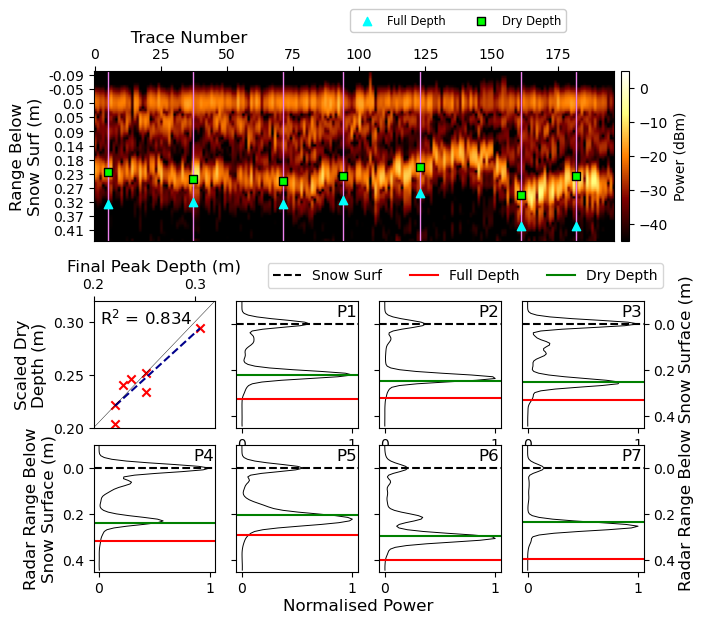

96.39595986963236
[np.float64(0.2197265625), np.float64(0.24261474609375), np.float64(0.24261474609375), np.float64(0.23345947265625), np.float64(0.2105712890625), np.float64(0.27923583984375), np.float64(0.2471923828125)]


/tmp/ipykernel_114856/938385648.py:81: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=[0.1,0.5,0.2])
/tmp/ipykernel_114856/938385648.py:88: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f'{over_dir}/Ka_echogram.png',dpi=500,bbox_inches='tight')
/home/robbie/anaconda3/envs/flood/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


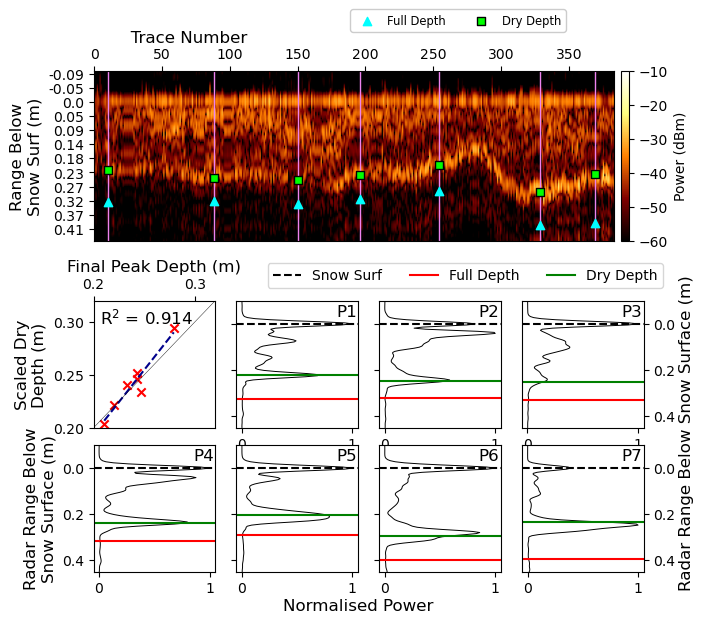

In [36]:
for freq in freqs:
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120
        
    yaxis=data_dict[freq]['yaxis']
    mean_wfms=data_dict[freq]['mean_wfms']
    radar_scat=data_dict[freq]['radar_scats']
        
    fig=plt.figure(constrained_layout=True,figsize=(8,6.5))
    gs = fig.add_gridspec(ncols=5, nrows=5,height_ratios=[0.5,0.7,0.2,1,1],width_ratios=[1,1,1,1,0.4])
    ax = fig.add_subplot(gs[0:2, :])
    
    make_echogram(ax,freq=freq,leg_pad=1.3)
    axs=[]
    for i,j in itertools.product(range(3,5),range(0,4)):
        axs.append(fig.add_subplot(gs[i,j]))

    
    ratios=[]
    for mean_wfm,ssd,swd,ax,count in zip(mean_wfms,scaled_snow_depths,scaled_dry_depths,axs[1:],range(1,8)):
        ax.plot(mean_wfm/np.max(mean_wfm),yaxis,color='k',lw=0.7)
        ax.axhline(0,color='k',ls='--',label='Snow Surf')
        ax.axhline(ssd,color='r',label='Full Depth')
        ax.axhline(swd,color='g',label='Dry Depth')
        ax.set_ylim(0.45,-0.1)
        ax.annotate(text=f'P{count}',
                    xy=(0.99,0.97),ha='right',va='top',
                    xycoords='axes fraction',fontsize='large')

        power_dry = mean_wfm[np.argmin(np.abs(yaxis-ssd))]
        power_wet = mean_wfm[np.argmin(np.abs(yaxis-swd))]
        ratios.append(power_wet/power_dry)

    print(np.nanmean(ratios))

    
    ax1=axs[0]
    
    ax1.scatter(radar_scat,scaled_dry_depths,color='r',marker='x')
    print(radar_scat)
    lr = linregress(radar_scat,scaled_dry_depths)
    
    ax1.plot([np.min(radar_scat),np.max(radar_scat)],
             [np.min(radar_scat)*lr[0]+lr[1], np.max(radar_scat)*lr[0]+lr[1]],
             ls='--',color='darkblue')
    
    ax1.set_xlabel('Final Peak Depth (m)',fontsize='large')
    ax1.set_ylabel('Scaled Dry\nDepth (m)',fontsize='large')
    ax1.xaxis.set_label_position('top')
    ax1.xaxis.tick_top()
    
    ax1.set_xlim(0.2,0.32)
    ax1.set_ylim(0.2,0.32)
    ax1.plot([0.2,0.32],[0.2,0.32],color='k',lw=0.3)
    ax1.annotate(text=f'R$^2$ = {np.round(lr[2]**2,decimals=3)}',xy=(0.05,0.95),va='top',xycoords='axes fraction',fontsize='large')

    axst = (x for x in axs)
    ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8=axst

    for ax in [ax2,ax3,ax6,ax7]:
        ax.set_yticklabels([])
    for ax in [ax4,ax8]:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position('right')

    
    ax5.set_ylabel('Radar Range Below\nSnow Surface (m)',fontsize='large')

    ax8.annotate(text='Radar Range Below Snow Surface (m)',
                 fontsize='large',xy=(1.35,1.1),ha='center',va='center',
                xycoords='axes fraction',rotation=90)

    
    ax6.annotate(text='Normalised Power',fontsize='large',xy=(1,-0.3),ha='center',
                xycoords='axes fraction')

    ax2.legend(bbox_to_anchor=(0.2,1.2),ncols=3,loc='center left')

    fig.subplots_adjust(hspace=[0.1,0.5,0.2])

    if freq=='ku':
        over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'
        plt.savefig(f'{over_dir}/F2.png',dpi=500,bbox_inches='tight')
    else:
        over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/SuppFigs/'
        plt.savefig(f'{over_dir}/Ka_echogram.png',dpi=500,bbox_inches='tight')
    
    plt.show()

In [47]:
import string

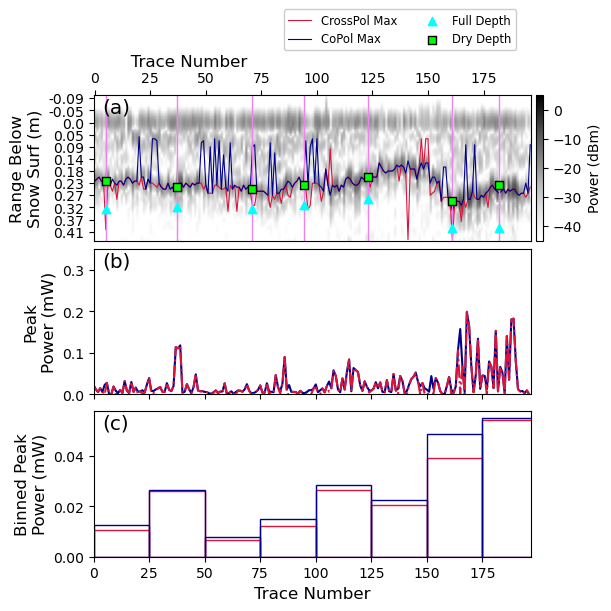

In [50]:
fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(6,6),constrained_layout=True,height_ratios=[1,1,1])

make_echogram(ax1,freq='ku',leg_pad=1.45,pol='vv',lines_on=True,cmap='Greys')

df=dfs['ku']
ax2.plot(df['p_amax'],color='darkblue')
ax2.plot(df['p_xmax'],ls='-.',color='crimson')
ax2.set_xlim(0,df.shape[0])
ax2.set_ylim(0,0.35)
ax2.set_xticklabels([])
ax2.set_ylabel('Peak\nPower (mW)',fontsize='large')

q=bs(np.arange(df.shape[0]),df['p_xmax'],bins=np.arange(0,226,25))
ax3.bar(12.5+np.arange(0,225,25),list(q.statistic),width=25,facecolor='none',edgecolor='crimson')

q=bs(np.arange(df.shape[0]),df['p_amax'],bins=np.arange(0,226,25))
ax3.bar(12.5+np.arange(0,225,25),list(q.statistic),width=25,facecolor='none',edgecolor='darkblue')

ax3.set_xlim(0,df.shape[0])

ax3.set_ylabel('Binned Peak\nPower (mW)',fontsize='large')
ax3.set_xlabel('Trace Number',fontsize='large')

letters = string.ascii_lowercase
for ax,letter in zip([ax1,ax2,ax3],letters):
    xcoord=0.02
    ax.annotate(f'({letter})',
                fontsize='x-large',
                xy=(xcoord,0.98),va='top',xycoords='axes fraction')
    
ddir='/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/SuppFigs/'

plt.savefig(f'{ddir}02_Fig3.png',dpi=500,bbox_inches='tight')
    